# Polynomial Regression

#### Is an extension of linear regression algorithm (more in linear_regression.ipynb) that models relationship between the input feature data and the target variables as nth-degree polynomial. It can catch non-linear relationships in data by adding polynomial terms to the future.

## Model

#### It expands input features: $x\longrightarrow \left[ x, x^2, x^3,...,x^d \right]$
#### And trains the model on this new feature set.

#### So for example instead:

$$
\hat{y}=\omega_1x+b
$$

#### We got:

$$
\hat{y}=\omega_1x+\omega_2x^2+\omega_3x^3+...+\omega_dx^d+b
$$

#### Where:
#### $\hat{y}$ - predicted value
#### $\omega$ - weight
#### $x$ - feature
#### $b$ - bias

#### Still $\textbf{linear to weights}$ bun $\textbf{nonlinear to features}$.
#### Good for use for nonlinear data. When data looks skewed and linear regression algorithm can't handle them properly.
#### You can also add regularization (ridge/lasso, more in ridge_and_lasso_regression.ipynb) for better effects.

## Dataset

#### Position-salary data from Kaggle has been used as a dataset for his nonlinearity.

#### https://www.kaggle.com/datasets/techwaker/position-salary-dataset

## 1. Import necessary libraries

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Load and visualize dataset

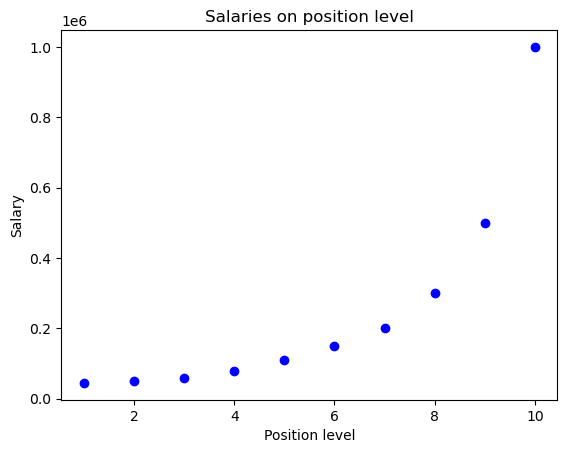

In [66]:
df = pd.read_csv('data/Position_Salaries.csv')
plt.scatter(df['Level'], df['Salary'], color='blue')
plt.title('Salaries on position level')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## 3. Split the data into training and testing sets

In [67]:
X = df['Level'].to_numpy().reshape(-1, 1)
y = df['Salary'].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Transform features into polynomial features

In [68]:
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 5. Initialize and train the model

In [69]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

## 6. Make predictions and evaluate the model

In [70]:
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
print('Mean squared error:', mse)

Mean squared error: 250686067.94793394


## 7. Visualize predictions

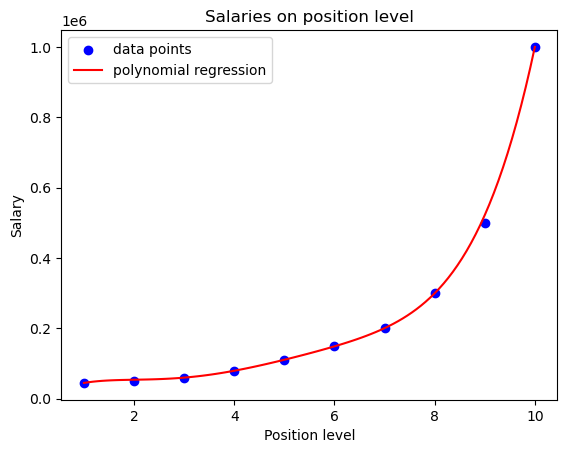

In [71]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = model.predict(poly.transform(X_plot))

plt.scatter(df['Level'], df['Salary'], color='blue', label='data points')
plt.plot(X_plot, y_plot, color='red', label='polynomial regression')
plt.title('Salaries on position level')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.legend()
plt.show()